In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from cmdstanpy import CmdStanModel
from pathlib import Path
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
from sklearn.calibration import calibration_curve
import joblib

In [2]:
PROJECT_ROOT = Path('../')
DATA_OUT     = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR  = PROJECT_ROOT / 'figures'
STAN_DIR     = PROJECT_ROOT / 'stan'
STAN_DIR.mkdir(exist_ok=True)

X_train = pd.read_csv(DATA_OUT / 'X_train.csv')
X_test  = pd.read_csv(DATA_OUT / 'X_test.csv')
y_train = pd.read_csv(DATA_OUT / 'y_train.csv').squeeze()
y_test  = pd.read_csv(DATA_OUT / 'y_test.csv').squeeze()

race_map = {1: 'Mexican American', 2: 'Other Hispanic', 3: 'NH White',
            4: 'NH Black', 6: 'NH Asian', 7: 'Other/Multi'}

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")

Train: (13200, 5)
Test:  (3301, 5)


In [3]:
feature_cols = ['LBXGH', 'BMXBMI', 'RIDAGEYR', 'RIAGENDR', 'cycle_2021']
feature_cols = [c for c in feature_cols if c in X_train.columns]

# Stan needs plain Python/numpy types — same pattern as the UBC site's list() in R
X_train_np = X_train[feature_cols].values.astype(float)
X_test_np  = X_test[feature_cols].values.astype(float)
y_train_np = y_train.values.astype(int)
y_test_np  = y_test.values.astype(int)

# Race group indexing — Stan uses 1-indexed integers
race_codes  = sorted(X_train['RIDRETH3'].unique())
race_to_idx = {code: i+1 for i, code in enumerate(race_codes)}
idx_to_race = {i+1: race_map[code] for i, code in enumerate(race_codes)}

race_idx_train = X_train['RIDRETH3'].map(race_to_idx).values.astype(int)
race_idx_test  = X_test['RIDRETH3'].map(race_to_idx).values.astype(int)

n_races    = len(race_codes)
n_features = len(feature_cols)

# This dict is passed directly to model.sample() — mirrors the UBC site's data=list(...)
data = {
    'N':         len(y_train_np),
    'K':         n_features,
    'J':         n_races,
    'X':         X_train_np.tolist(),
    'y':         y_train_np.tolist(),
    'race':      race_idx_train.tolist(),
    'N_test':    len(y_test_np),
    'X_test':    X_test_np.tolist(),
    'race_test': race_idx_test.tolist(),
}

print("Stan data fields:")
for k, v in data.items():
    shape = np.array(v).shape if isinstance(v, list) else v
    print(f"  {k}: {shape}")

Stan data fields:
  N: 13200
  K: 4
  J: 6
  X: (13200, 4)
  y: (13200,)
  race: (13200,)
  N_test: 3301
  X_test: (3301, 4)
  race_test: (3301,)


In [4]:
stan_code = """
// Hierarchical Bernoulli GLM — NHANES diabetes classification
// Model structure follows UBC STAT 405 w08 topic03 style:
// parameters -> transformed parameters (logistic mean) -> model (likelihood)

data {
  int<lower=0> N;                              // training observations
  int<lower=1> K;                              // number of features
  int<lower=1> J;                              // number of race groups
  array[N] int<lower=0, upper=1> y;            // diabetes label
  matrix[N, K] X;                              // feature matrix
  array[N] int<lower=1, upper=J> race;         // race group index (1-indexed)

  int<lower=0> N_test;                         // test observations
  matrix[N_test, K] X_test;                    // test feature matrix
  array[N_test] int<lower=1, upper=J> race_test;
}

parameters {
  // Hyperparameters for hierarchical intercepts
  real mu_alpha;
  real<lower=0> sigma_alpha;

  // Non-centered parameterization (same trick used in UBC site's examples)
  vector[J] alpha_offset;

  // Shared regression coefficients
  vector[K] beta;
}

transformed parameters {
  // Group intercepts — assembled here like the site assembles mu from parameters
  vector[J] alpha = mu_alpha + sigma_alpha * alpha_offset;

  // Predicted probability for each training observation
  // inv_logit is Stan's sigmoid — same role as inv_logit in the UBC Beta model
  vector[N] mu = inv_logit(alpha[race] + X * beta);
}

model {
  // Weakly informative priors — same philosophy as the UBC site's priors
  mu_alpha    ~ normal(0, 1);
  sigma_alpha ~ exponential(1);
  alpha_offset ~ normal(0, 1);
  beta        ~ normal(0, 1);

  // Bernoulli likelihood with logit parameterization
  y ~ bernoulli(mu);
}

generated quantities {
  // Posterior predictive probabilities for test set
  // Mirrors the UBC site's generated quantities pattern
  vector[N_test] mu_test =
    inv_logit(alpha[race_test] + X_test * beta);

  array[N_test] int y_test_rep;
  for (n in 1:N_test) {
    y_test_rep[n] = bernoulli_rng(mu_test[n]);
  }
}
"""

stan_file = STAN_DIR / 'nhanes_hierarchical_glm.stan'
with open(stan_file, 'w') as f:
    f.write(stan_code)

print(f"Stan model written to: {stan_file}")

Stan model written to: ../stan/nhanes_hierarchical_glm.stan


In [5]:
model = CmdStanModel(stan_file=str(stan_file))
print("Model compiled successfully")

fit = model.sample(
    data=data,
    chains=2,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    adapt_delta=0.9,
    show_progress=True,
    show_console=False
)

print("\nSampling complete")
print(fit.diagnose())

18:52:49 - cmdstanpy - INFO - compiling stan file /Users/sachleen/IUBDC-Project/stan/nhanes_hierarchical_glm.stan to exe file /Users/sachleen/IUBDC-Project/stan/nhanes_hierarchical_glm
18:52:55 - cmdstanpy - INFO - compiled model executable: /Users/sachleen/IUBDC-Project/stan/nhanes_hierarchical_glm


Model compiled successfully


18:52:55 - cmdstanpy - INFO - CmdStan start processing


chain 1:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

chain 2:   0%|          | 0/2000 [00:00<?, ?it/s, (Warmup)]

18:53:25 - cmdstanpy - INFO - CmdStan done processing.




Sampling complete
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [6]:
idata = az.from_cmdstanpy(fit)

summary = az.summary(
    idata,
    var_names=['mu_alpha', 'sigma_alpha', 'alpha', 'beta']
)

print("Posterior summary")
print(summary[['mean', 'sd', 'eti89_lb', 'eti89_ub', 'r_hat', 'ess_bulk']].round(3))

summary['r_hat'] = pd.to_numeric(summary['r_hat'], errors='coerce')

rhat_issues = summary[summary['r_hat'] > 1.01]
if len(rhat_issues) > 0:
    print(f"\nWARNING: {len(rhat_issues)} parameters with R-hat > 1.01")
    print(rhat_issues['r_hat'])
else:
    print("\nAll R-hat < 1.01 — convergence looks good")

Posterior summary
               mean     sd eti89_lb eti89_ub r_hat  ess_bulk
mu_alpha      -2.02  0.147     -2.2     -1.8  1.00       836
sigma_alpha   0.193   0.11    0.078     0.39  1.01       570
alpha[0]     -1.953   0.14     -2.2     -1.7  1.00      1972
alpha[1]     -2.043  0.137     -2.3     -1.8  1.00      2083
alpha[2]     -2.252  0.118     -2.4     -2.1  1.00      1733
alpha[3]     -1.995  0.118     -2.2     -1.8  1.00      2000
alpha[4]      -2.03   0.14     -2.3     -1.8  1.00      1978
alpha[5]     -1.928  0.156     -2.2     -1.7  1.00      1827
beta[0]       1.892  0.052      1.8        2  1.00      2504
beta[1]       0.263  0.031     0.22     0.31  1.00      1907
beta[2]       0.853  0.044     0.79     0.92  1.00      2051
beta[3]      -0.236  0.065    -0.34    -0.13  1.00      1736

All R-hat < 1.01 — convergence looks good


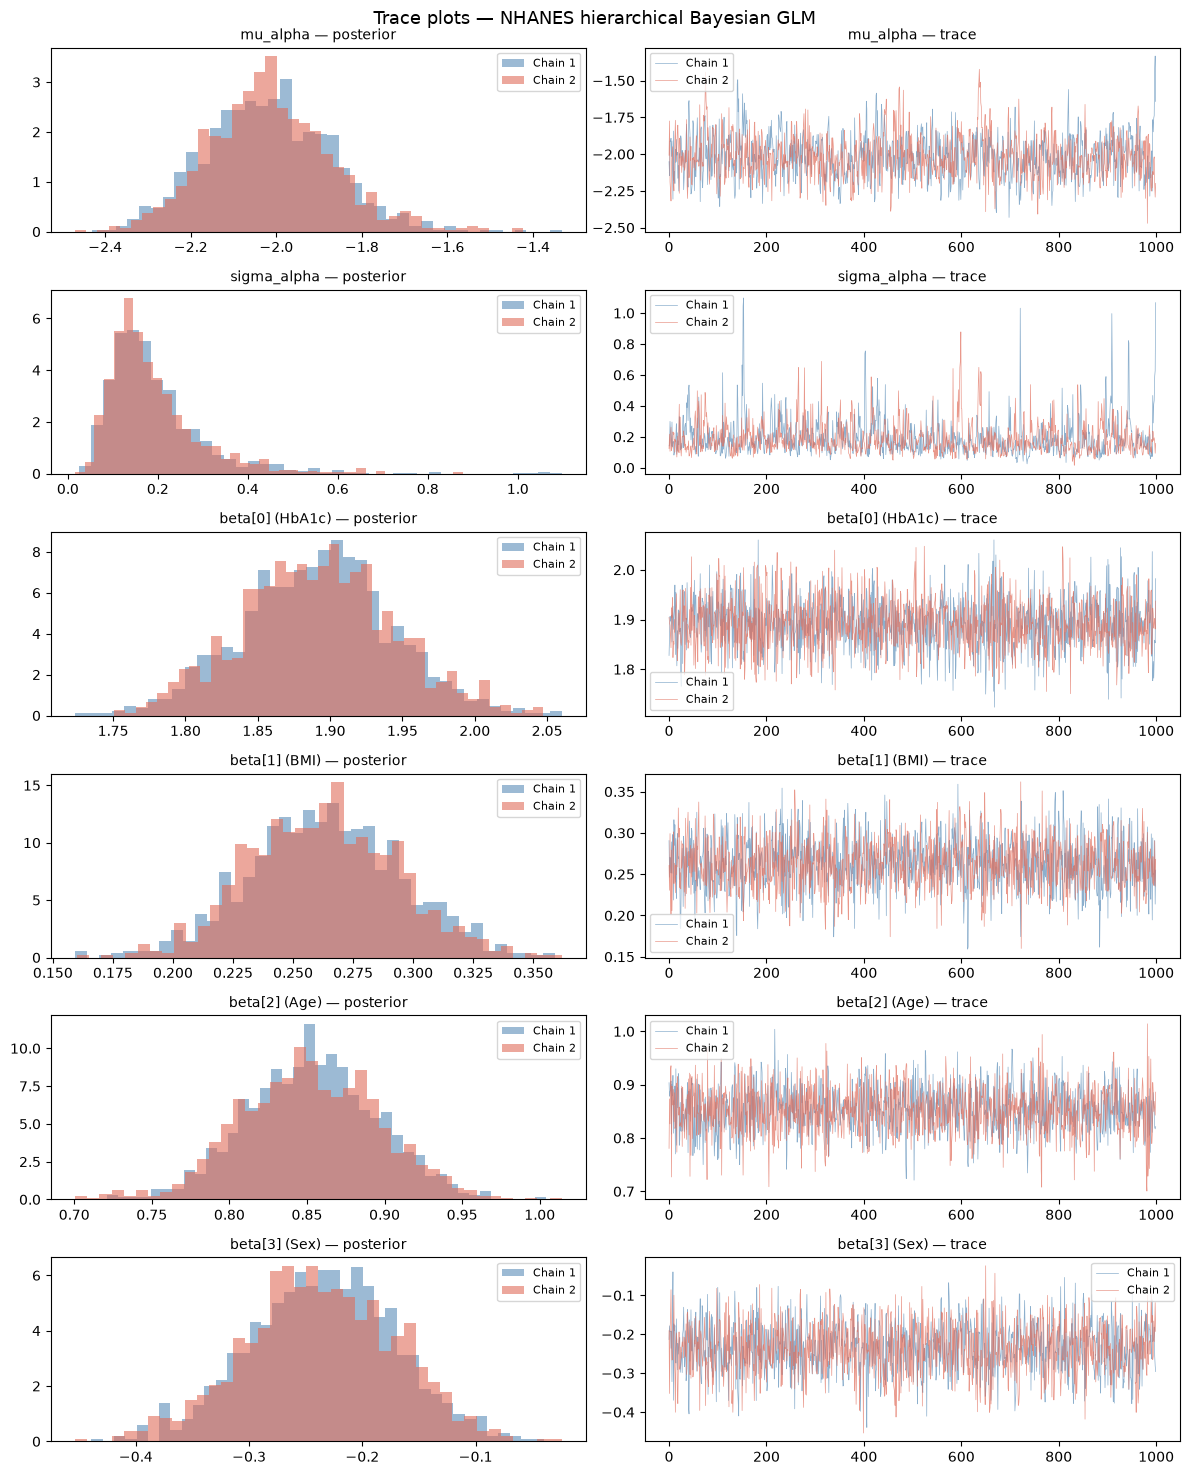

In [7]:
mu_alpha_samples    = fit.stan_variable('mu_alpha')      # shape: (2000,)
sigma_alpha_samples = fit.stan_variable('sigma_alpha')   # shape: (2000,)
beta_samples        = fit.stan_variable('beta')          # shape: (2000, K)

n_samples = len(mu_alpha_samples)
half      = n_samples // 2  # split into 2 chains of 1000 each

params = {
    'mu_alpha':    mu_alpha_samples,
    'sigma_alpha': sigma_alpha_samples,
    'beta[0] (HbA1c)':  beta_samples[:, 0],
    'beta[1] (BMI)':    beta_samples[:, 1],
    'beta[2] (Age)':    beta_samples[:, 2],
    'beta[3] (Sex)':    beta_samples[:, 3],
}

fig, axes = plt.subplots(len(params), 2, figsize=(12, 2.5 * len(params)))

for i, (name, samples) in enumerate(params.items()):
    # Left: posterior density
    axes[i, 0].hist(samples[:half],  bins=40, alpha=0.6, color='#5B8DB8', density=True, label='Chain 1')
    axes[i, 0].hist(samples[half:],  bins=40, alpha=0.6, color='#E06C5A', density=True, label='Chain 2')
    axes[i, 0].set_title(f'{name} — posterior', fontsize=10)
    axes[i, 0].legend(fontsize=8)

    # Right: trace
    axes[i, 1].plot(samples[:half], alpha=0.7, color='#5B8DB8', linewidth=0.5, label='Chain 1')
    axes[i, 1].plot(samples[half:], alpha=0.7, color='#E06C5A', linewidth=0.5, label='Chain 2')
    axes[i, 1].set_title(f'{name} — trace', fontsize=10)
    axes[i, 1].legend(fontsize=8)

plt.suptitle('Trace plots — NHANES hierarchical Bayesian GLM', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_bayes_trace.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# mu_test shape: (chains * draws, N_test) = (2000, N_test)
mu_test_samples = fit.stan_variable('mu_test')

bayes_proba_mean = mu_test_samples.mean(axis=0)
bayes_proba_std  = mu_test_samples.std(axis=0)

print(f"mu_test_samples shape: {mu_test_samples.shape}")
print(f"Mean predicted probability: {bayes_proba_mean.mean():.3f}")
print(f"Predicted diabetic (>0.5):  {(bayes_proba_mean > 0.5).mean():.1%}")
print(f"Test AUC: {roc_auc_score(y_test_np, bayes_proba_mean):.4f}")

mu_test_samples shape: (2000, 3301)
Mean predicted probability: 0.155
Predicted diabetic (>0.5):  9.4%
Test AUC: 0.8987


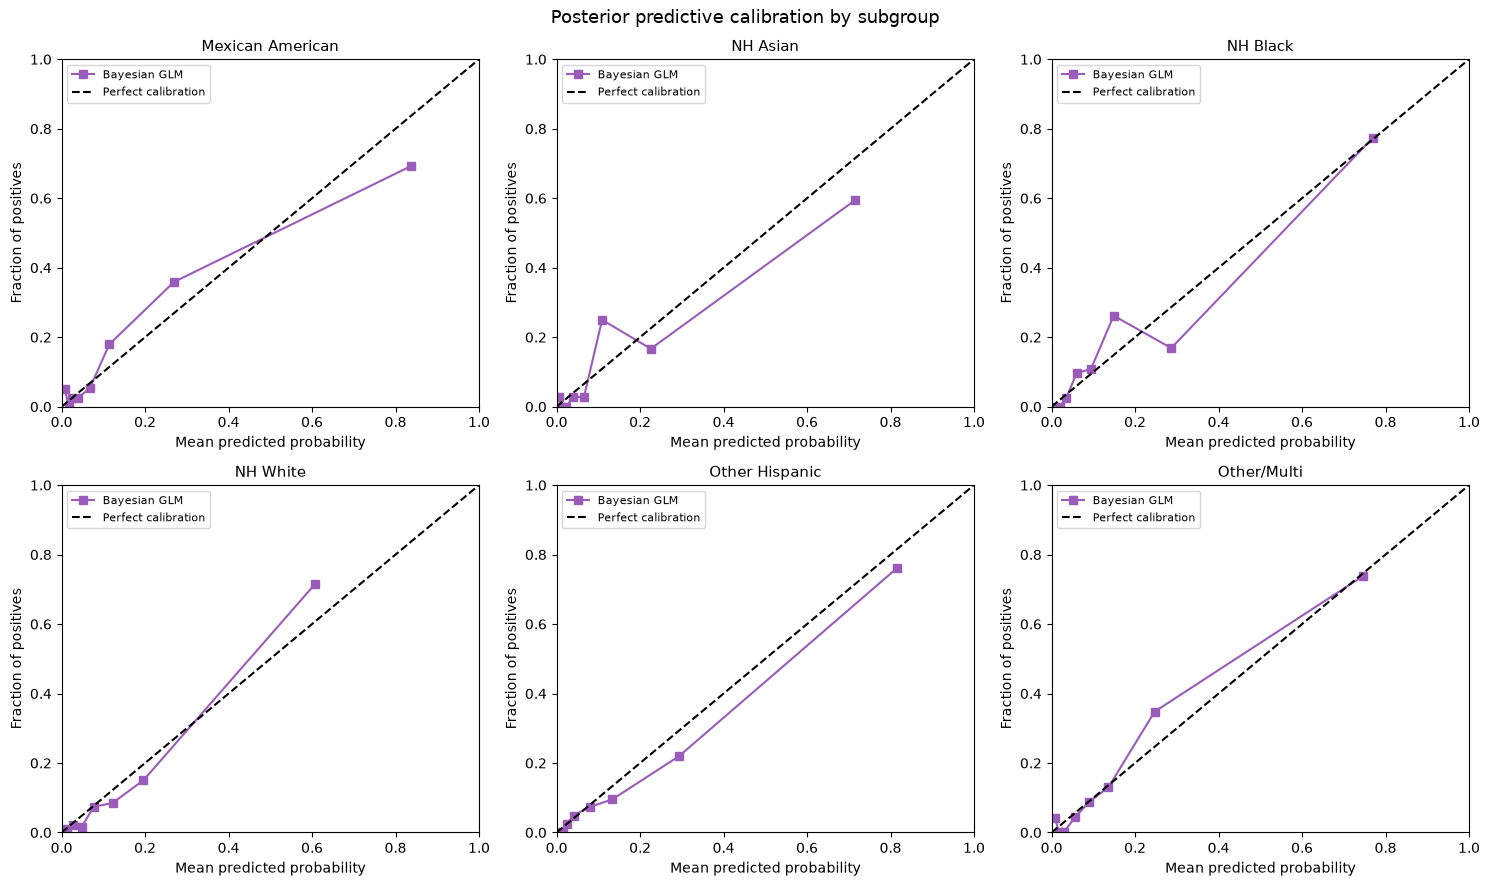

In [9]:
groups_test = X_test['RIDRETH3'].map(race_map)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, group_label in enumerate(sorted(groups_test.unique())):
    mask  = (groups_test == group_label).values
    proba = bayes_proba_mean[mask]
    y_grp = y_test_np[mask]

    frac_pos, mean_pred = calibration_curve(
        y_grp, proba, n_bins=8, strategy='quantile'
    )

    axes[i].plot(mean_pred, frac_pos, 's-', color='#9B5BB8', label='Bayesian GLM')
    axes[i].plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    axes[i].set_title(group_label, fontsize=11)
    axes[i].set_xlabel('Mean predicted probability')
    axes[i].set_ylabel('Fraction of positives')
    axes[i].legend(fontsize=8)
    axes[i].set_xlim(0, 1)
    axes[i].set_ylim(0, 1)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Posterior predictive calibration by subgroup', fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_bayes_calibration_by_race.png', dpi=150)
plt.show()

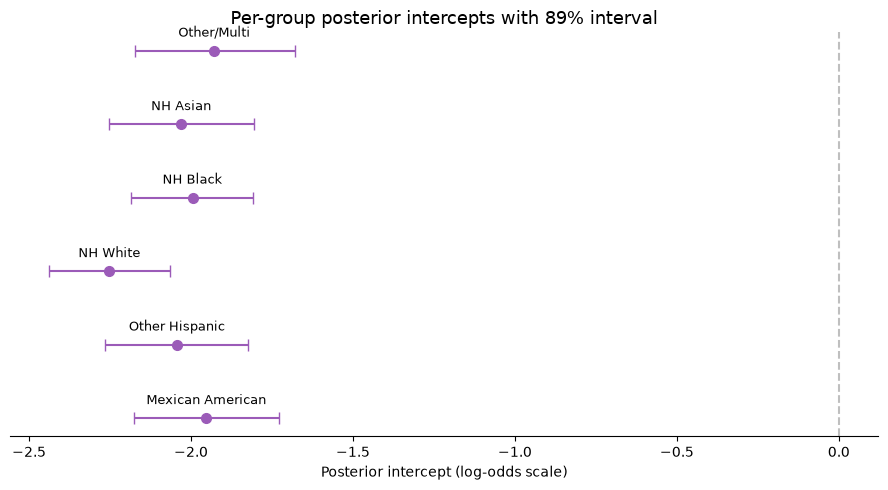

In [10]:
alpha_samples = fit.stan_variable('alpha')  # shape: (2000, J)

fig, ax = plt.subplots(figsize=(9, 5))

for j in range(n_races):
    samples = alpha_samples[:, j]
    label   = idx_to_race[j+1]
    mean    = samples.mean()
    lb      = np.percentile(samples, 5.5)   # 89% interval lower bound
    ub      = np.percentile(samples, 94.5)  # 89% interval upper bound

    ax.errorbar(
        mean, j,
        xerr=[[mean - lb], [ub - mean]],
        fmt='o', color='#9B5BB8', capsize=4, markersize=7
    )
    ax.text(mean, j + 0.15, label, ha='center', va='bottom', fontsize=9)

ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks([])
ax.set_xlabel('Posterior intercept (log-odds scale)')
ax.set_title('Per-group posterior intercepts with 89% interval', fontsize=13)
sns.despine(left=True)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'fig_bayes_group_intercepts.png', dpi=150)
plt.show()

In [11]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

results = []
for group_label in sorted(groups_test.unique()):
    mask  = (groups_test == group_label).values
    p_grp = bayes_proba_mean[mask]
    y_grp = y_test_np[mask]
    pred  = (p_grp > 0.5).astype(int)

    results.append({
        'group_type': 'race',
        'group':      group_label,
        'n':          len(y_grp),
        'n_diabetic': int(y_grp.sum()),
        'prevalence': float(y_grp.mean()),
        'auc':        roc_auc_score(y_grp, p_grp),
        'f1':         f1_score(y_grp, pred, zero_division=0),
        'precision':  precision_score(y_grp, pred, zero_division=0),
        'recall':     recall_score(y_grp, pred, zero_division=0),
        'model':      'bayes_hierarchical',
    })

bayes_metrics = pd.DataFrame(results).round(4)
bayes_metrics.to_csv(DATA_OUT / 'metrics_bayes.csv', index=False)

master = pd.read_csv(DATA_OUT / 'all_model_metrics.csv')
master = pd.concat([master, bayes_metrics], ignore_index=True)
master.to_csv(DATA_OUT / 'all_model_metrics.csv', index=False)

idata.to_netcdf(str(DATA_OUT / 'bayes_trace.nc'))
print("All outputs saved")
print(bayes_metrics[['group', 'auc', 'f1', 'recall', 'precision']].to_string(index=False))

All outputs saved
           group    auc     f1  recall  precision
Mexican American 0.8761 0.5806  0.5000     0.6923
        NH Asian 0.8784 0.5714  0.5000     0.6667
        NH Black 0.8835 0.6178  0.4917     0.8310
        NH White 0.9135 0.6384  0.4876     0.9245
  Other Hispanic 0.9120 0.7021  0.6471     0.7674
     Other/Multi 0.8927 0.6538  0.5312     0.8500
